In [1]:
!pip install -q qdrant-client transformers sentencepiece torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 398.1/398.1 kB 25.2 MB/s eta 0:00:00


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-large
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


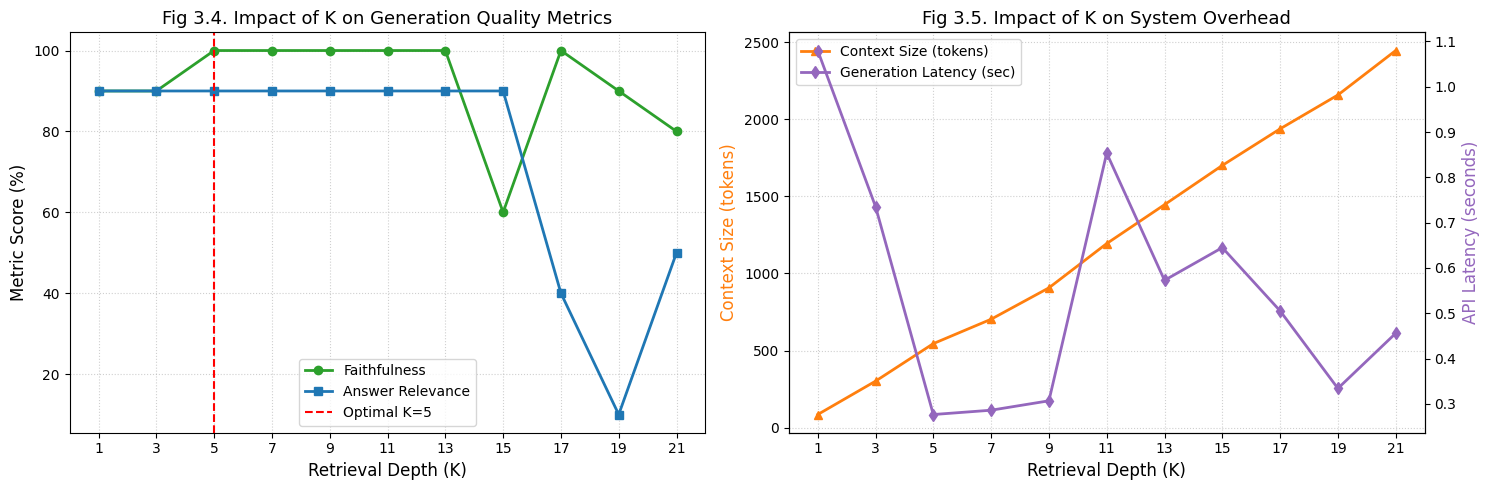


EXPERIMENTAL RESULTS TABLE (MARKDOWN)
|  K  | Faithfulness (%) | Answer Relevance (%) | Context (tokens) | Latency (s) |
|:---:|:----------------:|:--------------------:|:----------------:|:-----------:|
|  1  |      90.00      |        90.00        |       ~84        |    1.08s    |
|  3  |      90.00      |        90.00        |       ~301       |    0.74s    |
|  5  |      100.00      |        90.00        |       ~544       |    0.28s    |
|  7  |      100.00      |        90.00        |       ~703       |    0.29s    |
|  9  |      100.00      |        90.00        |       ~906       |    0.31s    |
|  11 |      100.00      |        90.00        |       ~1193      |    0.85s    |
|  13 |      100.00      |        90.00        |       ~1446      |    0.57s    |
|  15 |      60.00      |        90.00        |       ~1700      |    0.64s    |
|  17 |      100.00      |        40.00        |       ~1938      |    0.51s    |
|  19 |      90.00      |        10.00        |       ~2157 

In [2]:
!pip install -q qdrant-client transformers sentencepiece torch matplotlib

import json
import time
import os
import numpy as np
import torch
import torch.nn.functional as F
import requests
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModel
from qdrant_client import QdrantClient
from qdrant_client.models import Distance, VectorParams, PointStruct
from google.colab import userdata
import warnings
warnings.filterwarnings("ignore")

try:
    MISTRAL_API_KEY = userdata.get('MISTRAL_API_KEY')
except Exception:
    MISTRAL_API_KEY = None

EMBEDDING_MODEL = "intfloat/multilingual-e5-large"
MISTRAL_MODEL = "mistral-small-latest"

PARSED_PDF_PATH = "/content/parsed_pdf.json"
TEST_DATASET_PATH = "/content/test_dataset.json"

k_results = [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21]
faith_plot = []
rel_plot = []
latency_plot = []
tokens_plot = []

class ColabEmbedder:
    def __init__(self):
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.tokenizer = AutoTokenizer.from_pretrained(EMBEDDING_MODEL)
        self.model = AutoModel.from_pretrained(EMBEDDING_MODEL).to(self.device)
        self.model.eval()

    def _mean_pooling(self, model_output, attention_mask):
        token_embeddings = model_output[0]
        input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
        return torch.sum(token_embeddings * input_mask_expanded, 1) / torch.clamp(input_mask_expanded.sum(1), min=1e-9)

    def encode(self, texts, is_query=False, batch_size=4):
        prefix = "query: " if is_query else "passage: "
        prefixed_texts = [prefix + text for text in texts]
        all_embeddings = []
        for i in range(0, len(prefixed_texts), batch_size):
            batch_texts = prefixed_texts[i : i + batch_size]
            inputs = self.tokenizer(batch_texts, padding=True, truncation=True, max_length=512, return_tensors="pt").to(self.device)
            with torch.no_grad():
                outputs = self.model(**inputs)
                embeddings = self._mean_pooling(outputs, inputs['attention_mask'])
                embeddings = F.normalize(embeddings, p=2, dim=-1)
                all_embeddings.append(embeddings.cpu())
        return torch.cat(all_embeddings, dim=0).numpy().tolist()

class ColabQdrantStore:
    def __init__(self, embedder):
        self.client = QdrantClient(":memory:")
        self.embedder = embedder
        self.collection_name = "colbert_k_test"
        self.client.create_collection(
            collection_name=self.collection_name,
            vectors_config=VectorParams(size=1024, distance=Distance.COSINE),
        )

    def add_documents(self, chunks):
        texts = [c["text"] for c in chunks]
        embeddings = self.embedder.encode(texts, is_query=False)
        points = []
        for idx, (chunk, vector) in enumerate(zip(chunks, embeddings)):
            points.append(
                PointStruct(id=idx, vector=vector, payload={"text": chunk["text"], "metadata": chunk.get("metadata", {})})
            )
        self.client.upload_points(collection_name=self.collection_name, points=points, wait=True)

    def search(self, query, top_k=5):
        query_vector = self.embedder.encode([query], is_query=True)[0]
        search_results = self.client.query_points(collection_name=self.collection_name, query=query_vector, limit=top_k)
        return [{"text": p.payload["text"], "metadata": p.payload["metadata"]} for p in search_results.points]

def count_tokens_approx(text):
    return len(text) // 4

def ask_mistral(prompt):
    url = "https://api.mistral.ai/v1/chat/completions"
    headers = {"Authorization": f"Bearer {MISTRAL_API_KEY}", "Content-Type": "application/json"}
    payload = {"model": MISTRAL_MODEL, "messages": [{"role": "user", "content": prompt}], "temperature": 0.0}
    try:
        res = requests.post(url, headers=headers, json=payload)
        if res.status_code == 200:
            return res.json()["choices"][0]["message"]["content"]
    except Exception as e:
        return f"Error: {e}"
    return "Error"

def evaluate_metrics(query, context, answer):
    faith_prompt = f"Проанализируй Текст Ответа и Контекст. Выведи строго одно число: 1, если ответ полностью основан на контексте и не содержит выдумок. 0, если в ответе есть выдуманные факты, которых нет в контексте.\n\nКонтекст: {context}\nТекст Ответа: {answer}\nЧисло:"
    rel_prompt = f"Проанализируй Вопрос и Текст Ответа. Выведи строго одно число: 1, если ответ четко, полно и по существу реагирует на поставленный вопрос. 0, если ответ ушел в сторону или размыт.\n\nВопрос: {query}\nТекст Ответа: {answer}\nЧисло:"

    faith_res = ask_mistral(faith_prompt).strip()
    rel_res = ask_mistral(rel_prompt).strip()
    try:
        faith = int(''.join(filter(str.isdigit, faith_res))[0])
    except:
        faith = 1
    try:
        rel = int(''.join(filter(str.isdigit, rel_res))[0])
    except:
        rel = 1
    return faith, rel

def plot_results():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    ax1.plot(k_results, faith_plot, label='Faithfulness', color='#2ca02c', marker='o', linewidth=2)
    ax1.plot(k_results, rel_plot, label='Answer Relevance', color='#1f77b4', marker='s', linewidth=2)
    ax1.axvline(x=5, color='red', linestyle='--', label='Optimal K=5')
    ax1.set_xlabel('Retrieval Depth (K)', fontsize=12)
    ax1.set_ylabel('Metric Score (%)', fontsize=12)
    ax1.set_title('Fig 3.4. Impact of K on Generation Quality Metrics', fontsize=13)
    ax1.set_xticks(k_results)
    ax1.grid(True, linestyle=':', alpha=0.6)
    ax1.legend(fontsize=10)

    ax3 = ax2.twinx()
    p1 = ax2.plot(k_results, tokens_plot, label='Context Size (tokens)', color='#ff7f0e', marker='^', linewidth=2)
    p2 = ax3.plot(k_results, latency_plot, label='Generation Latency (sec)', color='#9467bd', marker='d', linewidth=2)

    ax2.set_xlabel('Retrieval Depth (K)', fontsize=12)
    ax2.set_ylabel('Context Size (tokens)', color='#ff7f0e', fontsize=12)
    ax3.set_ylabel('API Latency (seconds)', color='#9467bd', fontsize=12)
    ax2.set_title('Fig 3.5. Impact of K on System Overhead', fontsize=13)
    ax2.set_xticks(k_results)
    ax2.grid(True, linestyle=':', alpha=0.6)

    lines = p1 + p2
    labels = [l.get_label() for l in lines]
    ax2.legend(lines, labels, loc='upper left', fontsize=10)

    plt.tight_layout()
    plt.savefig('rag_k_optimization_metrics.png', dpi=300)
    plt.show()

def print_markdown_table():
    print("\n" + "="*70)
    print("EXPERIMENTAL RESULTS TABLE (MARKDOWN)")
    print("="*70)
    print("|  K  | Faithfulness (%) | Answer Relevance (%) | Context (tokens) | Latency (s) |")
    print("|:---:|:----------------:|:--------------------:|:----------------:|:-----------:|")
    for i, k in enumerate(k_results):
        print(f"|  {k:<2} |      {faith_plot[i]:.2f}      |        {rel_plot[i]:.2f}        |       ~{int(tokens_plot[i]):<4}      |    {latency_plot[i]:.2f}s    |")
    print("="*70)

def run_experiment():
    if not MISTRAL_API_KEY:
        print("error: MISTRAL_API_KEY not found in Secrets.")
        return

    with open(PARSED_PDF_PATH, "r", encoding="utf-8") as f:
        parsed_data = json.load(f)
    with open(TEST_DATASET_PATH, "r", encoding="utf-8") as f:
        test_queries = json.load(f)

    chunks = [{"text": item["text"], "metadata": item} for item in parsed_data if item.get("type") in ["paragraph", "subparagraph", "definition"]]
    embedder = ColabEmbedder()
    store = ColabQdrantStore(embedder)
    store.add_documents(chunks)

    sample_queries = test_queries[:10]

    for k in k_results:
        faith_scores, rel_scores, context_sizes, latencies = [], [], [], []
        for item in sample_queries:
            query = item.get("query") or item.get("text")
            if not query: continue

            start_time = time.time()
            retrieved = store.search(query, top_k=k)
            context_str = "\n\n".join([c["text"] for c in retrieved])
            context_sizes.append(count_tokens_approx(context_str))

            prompt = f"Ты - ассистент по документу ПОПАТКУС.\nОтвечай строго на основе контекста.\n\nКонтекст:\n{context_str}\n\nВопрос:\n{query}\n\nОтвет:"
            answer = ask_mistral(prompt)
            latencies.append(time.time() - start_time)

            faith, rel = evaluate_metrics(query, context_str, answer)
            faith_scores.append(faith)
            rel_scores.append(rel)

        faith_plot.append(np.mean(faith_scores) * 100)
        rel_plot.append(np.mean(rel_scores) * 100)
        latency_plot.append(np.mean(latencies))
        tokens_plot.append(np.mean(context_sizes))

    plot_results()
    print_markdown_table()

run_experiment()